In [1]:
print("Hi")

Hi


In [41]:
from pathlib import Path
from datetime import datetime, timezone
import json
import pickle
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)


In [ ]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "session_model_data" / "fastf1_cache").exists():
    possible_root = PROJECT_ROOT.parent
    if (possible_root / "session_model_data" / "fastf1_cache").exists():
        PROJECT_ROOT = possible_root

CACHE_DIR = PROJECT_ROOT / "session_model_data" / "fastf1_cache"
OUTPUT_DIR = PROJECT_ROOT / "module_2_lap_time_prediction_v2"
DATA_DIR = OUTPUT_DIR / "data"
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"

DATA_PATH = DATA_DIR / "lap_time_features_v2.csv"
MODEL_PATH = ARTIFACT_DIR / "lap_time_model_v2.joblib"
METRICS_PATH = ARTIFACT_DIR / "metrics_v2.json"
PREDICTIONS_PATH = ARTIFACT_DIR / "test_predictions_v2.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [43]:
print("Project root:", PROJECT_ROOT)
print("FastF1 cache:", CACHE_DIR)
print("Version 2 output:", OUTPUT_DIR)

Project root: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project
FastF1 cache: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/session_model_data/fastf1_cache
Version 2 output: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/module_2_lap_time_prediction_v2


In [44]:
def load_cached(path):
    """Load a FastF1 pickle wrapper and return its data payload."""
    with Path(path).open("rb") as file:
        payload = pickle.load(file)
    if isinstance(payload, dict) and "data" in payload:
        return payload["data"]
    return payload

In [45]:
def to_seconds(series):
    """Convert timedelta-like values into floating-point seconds."""
    return pd.to_timedelta(series, errors="coerce").dt.total_seconds()

In [46]:
def get_session_metadata(session_dir):
    info = load_cached(session_dir / "session_info.ff1pkl")
    meeting = info.get("Meeting", {})
    circuit = meeting.get("Circuit", {})
    return {
        "season": int(info["StartDate"].year),
        "event_name": meeting.get("Name", session_dir.parent.name),
        "circuit": circuit.get(
            "ShortName",
            meeting.get("Location", "Unknown"),
        ),
        "country": meeting.get("Country", {}).get("Name", "Unknown"),
        "session_name": info.get("Name", session_dir.name),
        "session_type": info.get("Type", "Unknown"),
    }

In [47]:
def get_driver_metadata(session_dir):
    raw_drivers = load_cached(session_dir / "driver_info.ff1pkl")
    rows = []
    for number, info in raw_drivers.items():
        rows.append({
            "driver_number": str(number),
            "driver": (
                info.get("Tla")
                or info.get("BroadcastName")
                or str(number)
            ),
            "team": info.get("TeamName") or "Unknown",
        })
    return pd.DataFrame(rows)

In [48]:
def attach_track_status(laps, session_dir):
    status_path = session_dir / "track_status_data.ff1pkl"
    if not status_path.exists():
        laps["track_status"] = "1"
        return laps

    status = pd.DataFrame(load_cached(status_path))
    if status.empty:
        laps["track_status"] = "1"
        return laps

    status["status_time_seconds"] = to_seconds(status["Time"])
    status = (
        status.dropna(subset=["status_time_seconds"])
        .sort_values("status_time_seconds")
    )
    laps = laps.sort_values("session_elapsed_seconds")

    merged = pd.merge_asof(
        laps,
        status[["status_time_seconds", "Status"]],
        left_on="session_elapsed_seconds",
        right_on="status_time_seconds",
        direction="backward",
    )
    merged["track_status"] = merged["Status"].fillna("1").astype(str)
    return merged.drop(columns=["status_time_seconds", "Status"])

In [49]:
def extract_one_session(session_dir):
    """Extract raw lap rows and metadata for one cached session."""
    timing_payload = load_cached(
        session_dir / "_extended_timing_data.ff1pkl"
    )
    timing = (
        timing_payload[0]
        if isinstance(timing_payload, tuple)
        else timing_payload
    ).copy()

    timing["driver_number"] = timing["Driver"].astype(str)
    timing["lap_time_seconds"] = to_seconds(timing["LapTime"])
    timing["session_elapsed_seconds"] = to_seconds(timing["Time"])
    timing["lap_number"] = pd.to_numeric(
        timing["NumberOfLaps"],
        errors="coerce",
    )
    timing["pit_out"] = timing["PitOutTime"].notna()
    timing["pit_in"] = timing["PitInTime"].notna()

    columns = [
        "driver_number",
        "lap_number",
        "session_elapsed_seconds",
        "lap_time_seconds",
        "pit_out",
        "pit_in",
        "SpeedI1",
        "SpeedI2",
        "SpeedFL",
        "SpeedST",
    ]
    laps = timing[columns].rename(columns={
        "SpeedI1": "speed_i1",
        "SpeedI2": "speed_i2",
        "SpeedFL": "speed_finish_line",
        "SpeedST": "speed_trap",
    })

    laps = laps.merge(
        get_driver_metadata(session_dir),
        on="driver_number",
        how="left",
    )
    for column, value in get_session_metadata(session_dir).items():
        laps[column] = value

    return attach_track_status(laps, session_dir)


In [50]:
def clean_and_engineer(raw_laps):
    data = raw_laps.copy()

    required = [
        "lap_time_seconds",
        "lap_number",
        "session_elapsed_seconds",
        "driver",
    ]
    data = data.dropna(subset=required)
    data = data.loc[~data["pit_out"] & ~data["pit_in"]]
    data = data.loc[data["lap_time_seconds"].between(45, 240)]

    session_keys = ["season", "event_name", "session_name"]
    grouped_target = data.groupby(session_keys)["lap_time_seconds"]

    session_median = grouped_target.transform("median")
    session_mad = grouped_target.transform(
        lambda values: np.median(
            np.abs(values - np.median(values))
        )
    )
    robust_scale = session_mad.replace(0, np.nan).fillna(5.0)
    outlier_distance = (
        data["lap_time_seconds"] - session_median
    ).abs()
    data = data.loc[outlier_distance <= 6 * robust_scale]

    sort_columns = (
        session_keys
        + ["driver", "lap_number", "session_elapsed_seconds"]
    )
    data = data.sort_values(sort_columns).reset_index(drop=True)

    driver_session_keys = session_keys + ["driver"]
    driver_session = data.groupby(
        driver_session_keys,
        sort=False,
    )

    # Every feature below is shifted: the target lap itself is never exposed.
    data["previous_lap_seconds"] = (
        driver_session["lap_time_seconds"].shift(1)
    )
    data["rolling_3_lap_median"] = (
        driver_session["lap_time_seconds"]
        .transform(
            lambda values: (
                values.shift(1)
                .rolling(3, min_periods=1)
                .median()
            )
        )
    )
    data["previous_speed_i1"] = driver_session["speed_i1"].shift(1)
    data["previous_speed_i2"] = driver_session["speed_i2"].shift(1)
    data["previous_speed_finish_line"] = (
        driver_session["speed_finish_line"].shift(1)
    )
    data["previous_speed_trap"] = (
        driver_session["speed_trap"].shift(1)
    )
    data["driver_session_lap_index"] = (
        driver_session.cumcount() + 1
    )

    # A next-lap prediction needs at least one previous valid lap.
    data = data.dropna(subset=["previous_lap_seconds"])
    return data.reset_index(drop=True)

In [51]:
def build_complete_dataset(cache_dir):
    timing_files = sorted(
        Path(cache_dir).rglob("_extended_timing_data.ff1pkl")
    )
    if not timing_files:
        raise FileNotFoundError(
            f"No FastF1 timing files found under {cache_dir}"
        )

    session_frames = []
    skipped_sessions = []

    for index, timing_file in enumerate(timing_files, start=1):
        session_dir = timing_file.parent
        required_files = [
            session_dir / "session_info.ff1pkl",
            session_dir / "driver_info.ff1pkl",
        ]
        if not all(path.exists() for path in required_files):
            skipped_sessions.append(str(session_dir))
            continue

        session_frames.append(extract_one_session(session_dir))

    raw_data = pd.concat(session_frames, ignore_index=True)
    clean_data = clean_and_engineer(raw_data)

    print(f"Cache sessions found: {len(timing_files)}")
    print(f"Sessions extracted: {len(session_frames)}")
    print(f"Sessions skipped: {len(skipped_sessions)}")
    print(f"Raw rows: {len(raw_data):,}")
    print(f"Model-ready rows: {len(clean_data):,}")

    return clean_data


In [52]:
REBUILD_DATA = True

if REBUILD_DATA or not DATA_PATH.exists():
    lap_data = build_complete_dataset(CACHE_DIR)
    lap_data.to_csv(DATA_PATH, index=False)
    print("Dataset saved:", DATA_PATH)
else:
    lap_data = pd.read_csv(DATA_PATH)
    print("Existing dataset loaded:", DATA_PATH)


Cache sessions found: 84
Sessions extracted: 84
Sessions skipped: 0
Raw rows: 31,481
Model-ready rows: 13,116
Dataset saved: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/module_2_lap_time_prediction_v2/data/lap_time_features_v2.csv


In [54]:
print(f"Rows: {len(lap_data):,}")
print(f"Seasons: {sorted(lap_data['season'].unique())}")
print(f"Events: {lap_data['event_name'].nunique()}")
print(f"Sessions: {lap_data['session_name'].nunique()}")
print(f"Drivers: {lap_data['driver'].nunique()}")

Rows: 13,116
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Events: 8
Sessions: 7
Drivers: 36


In [55]:
lap_data.head()

,driver_number,lap_number,session_elapsed_seconds,lap_time_seconds,pit_out,pit_in,speed_i1,speed_i2,speed_finish_line,speed_trap,driver,team,season,event_name,circuit,country,session_name,session_type,track_status,previous_lap_seconds,rolling_3_lap_median,previous_speed_i1,previous_speed_i2,previous_speed_finish_line,previous_speed_trap,driver_session_lap_index
0,23,4,1371.702,85.268,False,False,270.0,313.0,293.0,304.0,ALB,Williams,2022,Australian Grand Prix,Melbourne,Australia,Practice 1,Practice,1,87.522,87.522,267.0,310.0,292.0,295.0,2
1,23,6,1566.254,84.483,False,False,272.0,314.0,295.0,310.0,ALB,Williams,2022,Australian Grand Prix,Melbourne,Australia,Practice 1,Practice,1,85.268,86.395,270.0,313.0,293.0,304.0,3
2,23,8,1784.359,98.773,False,False,235.0,157.0,293.0,313.0,ALB,Williams,2022,Australian Grand Prix,Melbourne,Australia,Practice 1,Practice,1,84.483,85.268,272.0,314.0,295.0,310.0,4
3,23,9,1868.699,84.340,False,False,273.0,297.0,294.0,306.0,ALB,Williams,2022,Australian Grand Prix,Melbourne,Australia,Practice 1,Practice,1,98.773,85.268,235.0,157.0,293.0,313.0,5
4,23,13,2912.559,83.377,False,False,273.0,311.0,296.0,307.0,ALB,Williams,2022,Australian Grand Prix,Melbourne,Australia,Practice 1,Practice,1,84.340,84.483,273.0,297.0,294.0,306.0,6


In [56]:
print("Duplicate rows:", lap_data.duplicated().sum())
print("Missing target values:", lap_data["lap_time_seconds"].isna().sum())
print("Missing previous-lap values:",lap_data["previous_lap_seconds"].isna().sum(),)


Duplicate rows: 0
Missing target values: 0
Missing previous-lap values: 0


In [57]:
quality_table = pd.DataFrame({
    "data_type": lap_data.dtypes.astype(str),
    "missing_count": lap_data.isna().sum(),
    "missing_percent": (
        lap_data.isna().mean() * 100
    ).round(2),
    "unique_values": lap_data.nunique(),
})
quality_table.sort_values(
    "missing_percent",
    ascending=False,
).head(20)


,data_type,missing_count,missing_percent,unique_values
speed_i1,float64,1037,7.91,197
previous_speed_i1,float64,952,7.26,196
speed_trap,float64,287,2.19,252
previous_speed_trap,float64,257,1.96,246
previous_speed_i2,float64,1,0.01,251
driver_number,object,0,0.00,36
circuit,object,0,0.00,8
previous_speed_finish_line,float64,0,0.00,163
rolling_3_lap_median,float64,0,0.00,8532
previous_lap_seconds,float64,0,0.00,10294


In [58]:
lap_data["lap_time_seconds"].describe()


count    13116.000000
mean        93.547555
std          9.748841
min         75.096000
25%         88.419750
50%         93.479000
75%         98.202250
max        148.014000
Name: lap_time_seconds, dtype: float64

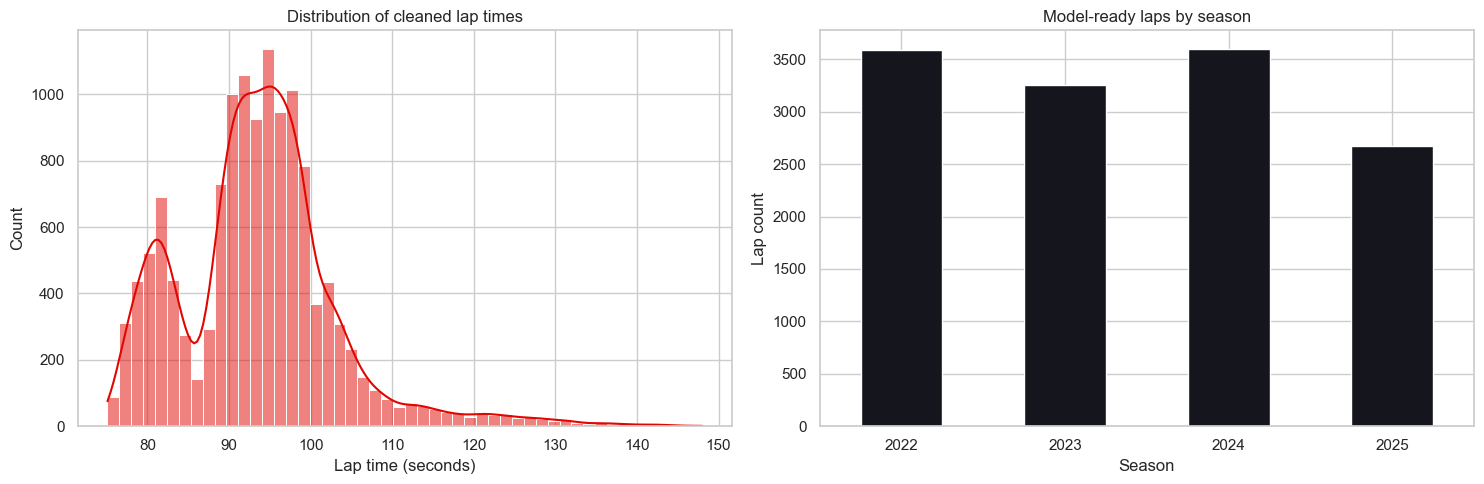

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    lap_data["lap_time_seconds"],
    bins=50,
    kde=True,
    color="#e10600",
    ax=axes[0],
)
axes[0].set_title("Distribution of cleaned lap times")
axes[0].set_xlabel("Lap time (seconds)")

season_counts = lap_data.groupby("season").size()
season_counts.plot(
    kind="bar",
    color="#15151e",
    ax=axes[1],
)
axes[1].set_title("Model-ready laps by season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Lap count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [60]:
event_summary = (
    lap_data.groupby(["season", "event_name"])
    .agg(
        usable_laps=("lap_time_seconds", "size"),
        median_lap_seconds=("lap_time_seconds", "median"),
        drivers=("driver", "nunique"),
    )
    .reset_index()
)
event_summary


,season,event_name,usable_laps,median_lap_seconds,drivers
0,2022,Australian Grand Prix,607,83.6800,20
1,2022,Bahrain Grand Prix,549,97.6560,20
2,2022,Emilia Romagna Grand Prix,1024,81.5675,20
3,2022,Miami Grand Prix,708,95.2315,20
4,2022,Saudi Arabian Grand Prix,699,95.7300,20
5,2023,Australian Grand Prix,856,84.3785,20
6,2023,Azerbaijan Grand Prix,532,105.0755,20
7,2023,Bahrain Grand Prix,596,97.9860,20
8,2023,Miami Grand Prix,602,92.6570,20
9,2023,Saudi Arabian Grand Prix,673,93.5730,20


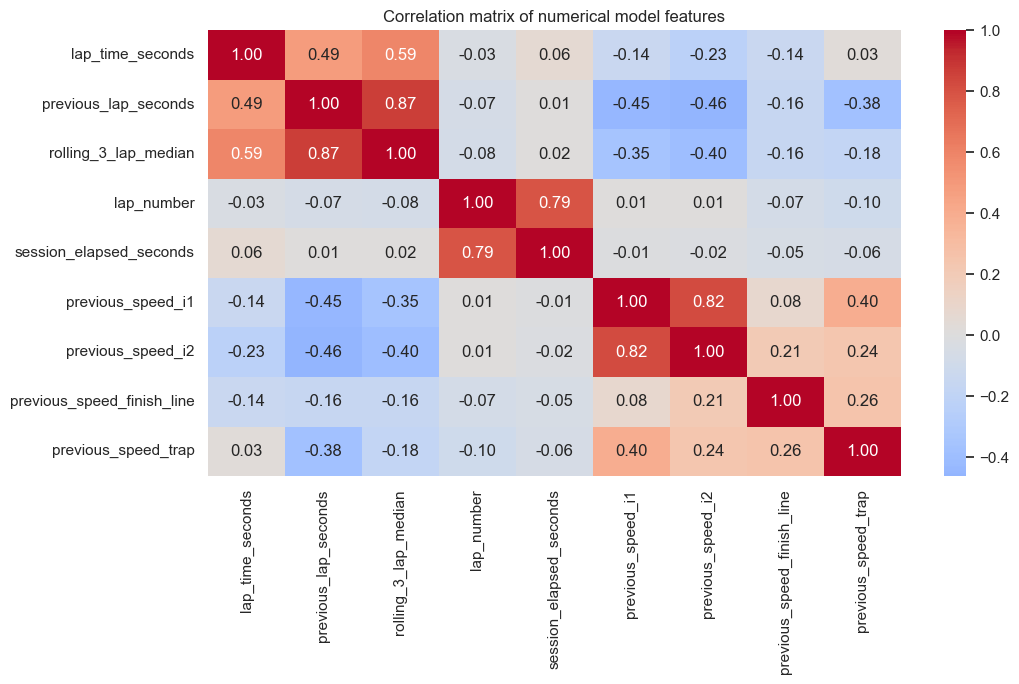

In [61]:
correlation_columns = [
    "lap_time_seconds",
    "previous_lap_seconds",
    "rolling_3_lap_median",
    "lap_number",
    "session_elapsed_seconds",
    "previous_speed_i1",
    "previous_speed_i2",
    "previous_speed_finish_line",
    "previous_speed_trap",
]

plt.figure(figsize=(11, 7))
sns.heatmap(
    lap_data[correlation_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Correlation matrix of numerical model features")
plt.tight_layout()
plt.show()


In [62]:
CATEGORICAL_FEATURES = [
    "event_name",
    "circuit",
    "country",
    "session_name",
    "session_type",
    "driver",
    "team",
    "track_status",
]

NUMERIC_FEATURES = [
    "season",
    "lap_number",
    "session_elapsed_seconds",
    "driver_session_lap_index",
    "previous_lap_seconds",
    "rolling_3_lap_median",
    "previous_speed_i1",
    "previous_speed_i2",
    "previous_speed_finish_line",
    "previous_speed_trap",
]

FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES
TARGET = "lap_time_seconds"

In [63]:
def create_preprocessor():
    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=2,
                sparse_output=False,
            ),
        ),
    ])

    numerical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
    ])

    return ColumnTransformer([
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES,
        ),
        (
            "numerical",
            numerical_pipeline,
            NUMERIC_FEATURES,
        ),
    ])

In [64]:
print("Feature count:", len(FEATURES))
display(pd.DataFrame({
    "categorical_features": pd.Series(CATEGORICAL_FEATURES),
    "numeric_features": pd.Series(NUMERIC_FEATURES),
}))

Feature count: 18


,categorical_features,numeric_features
0,event_name,season
1,circuit,lap_number
2,country,session_elapsed_seconds
3,session_name,driver_session_lap_index
4,session_type,previous_lap_seconds
5,driver,rolling_3_lap_median
6,team,previous_speed_i1
7,track_status,previous_speed_i2
8,NaN,previous_speed_finish_line
9,NaN,previous_speed_trap


In [65]:
class PreviousLapDeltaRegressor(RegressorMixin, BaseEstimator):
    """Learn a correction to the previous-lap persistence baseline."""

    def __init__(
        self,
        estimator,
        baseline_column="previous_lap_seconds",
    ):
        self.estimator = estimator
        self.baseline_column = baseline_column

    def fit(self, X, y):
        self.estimator_ = clone(self.estimator)
        baseline = np.asarray(
            X[self.baseline_column],
            dtype=float,
        )
        target_delta = np.asarray(y) - baseline
        self.estimator_.fit(X, target_delta)
        return self

    def predict(self, X):
        baseline = np.asarray(
            X[self.baseline_column],
            dtype=float,
        )
        return baseline + self.estimator_.predict(X)


def create_pipeline(regressor):
    return Pipeline([
        ("preprocessor", create_preprocessor()),
        ("regressor", regressor),
    ])


In [66]:
def build_candidate_models():
    models = {
        "gradient_boosting_delta": PreviousLapDeltaRegressor(
            create_pipeline(
                GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.03,
                    max_depth=3,
                    loss="huber",
                    random_state=42,
                )
            )
        ),
        "extra_trees": create_pipeline(
            ExtraTreesRegressor(
                n_estimators=350,
                min_samples_leaf=2,
                max_features=0.8,
                n_jobs=-1,
                random_state=42,
            )
        ),
        "random_forest": create_pipeline(
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                max_features=0.8,
                n_jobs=-1,
                random_state=42,
            )
        ),
    }

    try:
        from xgboost import XGBRegressor

        models["xgboost_delta"] = PreviousLapDeltaRegressor(
            create_pipeline(
                XGBRegressor(
                    n_estimators=700,
                    learning_rate=0.04,
                    max_depth=7,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    objective="reg:squarederror",
                    n_jobs=-1,
                    random_state=42,
                )
            )
        )
        print("XGBoost detected and included.")
    except ImportError:
        print("XGBoost not installed; skipping it.")

    try:
        from lightgbm import LGBMRegressor

        models["lightgbm_delta"] = PreviousLapDeltaRegressor(
            create_pipeline(
                LGBMRegressor(
                    n_estimators=700,
                    learning_rate=0.04,
                    num_leaves=40,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    random_state=42,
                    verbosity=-1,
                )
            )
        )
        print("LightGBM detected and included.")
    except ImportError:
        print("LightGBM not installed; skipping it.")

    return models


In [67]:
def calculate_metrics(actual, predicted):
    return {
        "mae_seconds": round(
            float(mean_absolute_error(actual, predicted)),
            4,
        ),
        "rmse_seconds": round(
            float(mean_squared_error(actual, predicted) ** 0.5),
            4,
        ),
        "r2": round(
            float(r2_score(actual, predicted)),
            4,
        ),
    }

In [68]:
TEST_SEASON = int(lap_data["season"].max())

train_data = lap_data[lap_data["season"] < TEST_SEASON].copy()
test_data = lap_data[lap_data["season"] == TEST_SEASON].copy()

if train_data.empty or test_data.empty:
    raise ValueError(
        "The chronological split requires earlier and latest-season data."
    )


In [69]:
X_train = train_data[FEATURES]
y_train = train_data[TARGET]
X_test = test_data[FEATURES]
y_test = test_data[TARGET]

In [70]:
print("Training seasons:", sorted(train_data["season"].unique()))
print("Test season:", TEST_SEASON)
print(f"Training rows: {len(train_data):,}")
print(f"Test rows: {len(test_data):,}")
print("Test events:", test_data["event_name"].nunique())

Training seasons: [np.int64(2022), np.int64(2023), np.int64(2024)]
Test season: 2025
Training rows: 10,443
Test rows: 2,673
Test events: 5


In [ ]:
baseline_prediction = X_test["previous_lap_seconds"].to_numpy()
baseline_metrics = calculate_metrics(
    y_test,
    baseline_prediction,
)

print("Previous-lap baseline:")
display(pd.DataFrame(
    [baseline_metrics],
    index=["previous_lap_baseline"],
))


Previous-lap baseline:


,mae_seconds,rmse_seconds,r2
previous_lap_baseline,1.5746,4.1217,0.6827


In [72]:
candidate_models = build_candidate_models()
trained_models = {}
prediction_map = {}
model_metrics = {}

for model_name, model in candidate_models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    predicted = model.predict(X_test)

    trained_models[model_name] = model
    prediction_map[model_name] = predicted
    model_metrics[model_name] = calculate_metrics(
        y_test,
        predicted,
    )

model_metrics["previous_lap_baseline"] = baseline_metrics

results_table = (
    pd.DataFrame(model_metrics)
    .T
    .sort_values("rmse_seconds")
)
results_table


XGBoost detected and included.
LightGBM detected and included.
Training gradient_boosting_delta...
Training extra_trees...
Training random_forest...
Training xgboost_delta...
Training lightgbm_delta...


,mae_seconds,rmse_seconds,r2
gradient_boosting_delta,2.0940,3.7007,0.7442
previous_lap_baseline,1.5746,4.1217,0.6827
xgboost_delta,2.6108,4.6623,0.5941
lightgbm_delta,2.8125,4.7273,0.5827
random_forest,2.8935,4.8244,0.5653
extra_trees,3.6640,5.9762,0.3330


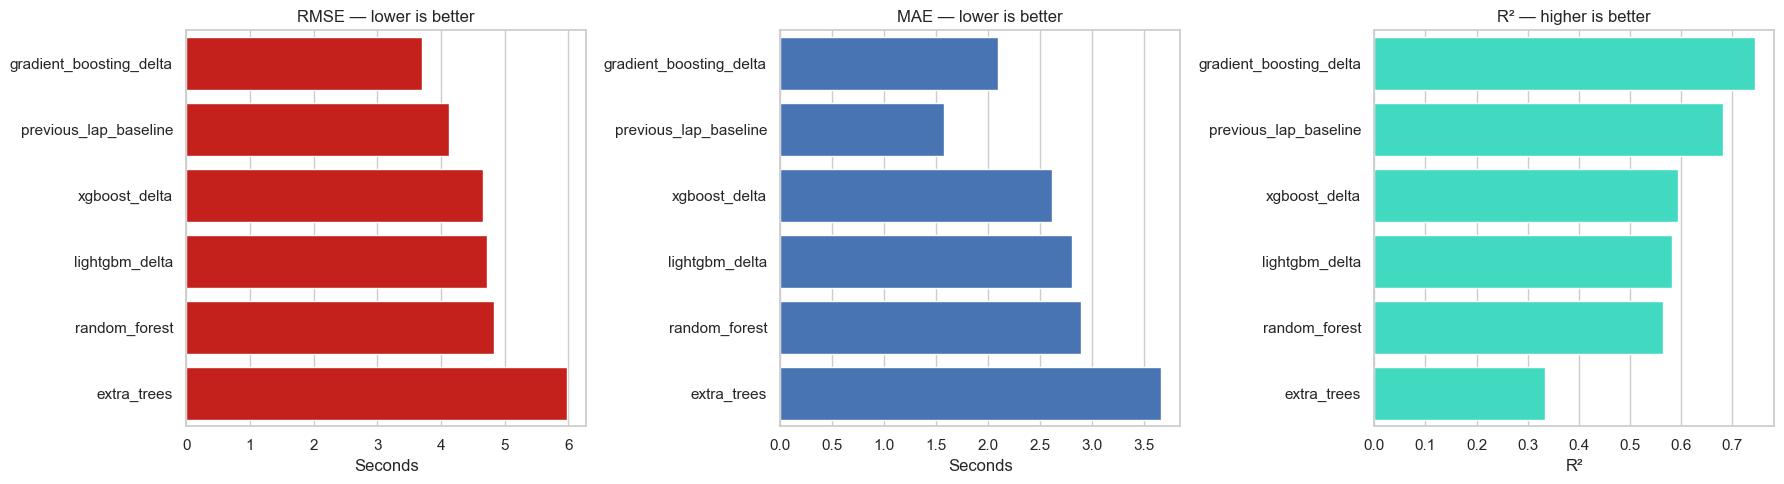

In [73]:
plot_table = (
    results_table.reset_index()
    .rename(columns={"index": "model"})
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=plot_table,
    x="rmse_seconds",
    y="model",
    color="#e10600",
    ax=axes[0],
)
axes[0].set_title("RMSE — lower is better")
axes[0].set_xlabel("Seconds")
axes[0].set_ylabel("")

sns.barplot(
    data=plot_table,
    x="mae_seconds",
    y="model",
    color="#3671c6",
    ax=axes[1],
)
axes[1].set_title("MAE — lower is better")
axes[1].set_xlabel("Seconds")
axes[1].set_ylabel("")

sns.barplot(
    data=plot_table,
    x="r2",
    y="model",
    color="#27f4d2",
    ax=axes[2],
)
axes[2].set_title("R² — higher is better")
axes[2].set_xlabel("R²")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


In [74]:
learned_model_names = list(trained_models)
BEST_MODEL_NAME = min(
    learned_model_names,
    key=lambda name: model_metrics[name]["rmse_seconds"],
)

best_model = trained_models[BEST_MODEL_NAME]
best_prediction = prediction_map[BEST_MODEL_NAME]

comparison = pd.DataFrame(
    [
        model_metrics[BEST_MODEL_NAME],
        baseline_metrics,
    ],
    index=[
        BEST_MODEL_NAME,
        "previous_lap_baseline",
    ],
)

print("Selected model:", BEST_MODEL_NAME)
comparison


Selected model: gradient_boosting_delta


,mae_seconds,rmse_seconds,r2
gradient_boosting_delta,2.0940,3.7007,0.7442
previous_lap_baseline,1.5746,4.1217,0.6827


In [75]:
evaluation = test_data[
    [
        "season",
        "event_name",
        "session_name",
        "driver",
        "team",
        "lap_number",
        TARGET,
    ]
].copy()

evaluation["predicted_lap_time_seconds"] = best_prediction
evaluation["residual_seconds"] = (
    evaluation[TARGET]
    - evaluation["predicted_lap_time_seconds"]
)
evaluation["absolute_error_seconds"] = (
    evaluation["residual_seconds"].abs()
)

evaluation.head()


,season,event_name,session_name,driver,team,lap_number,lap_time_seconds,predicted_lap_time_seconds,residual_seconds,absolute_error_seconds
10443,2025,Australian Grand Prix,Practice 1,ALB,Williams,5,80.470,83.448972,-2.978972,2.978972
10444,2025,Australian Grand Prix,Practice 1,ALB,Williams,7,98.116,85.224939,12.891061,12.891061
10445,2025,Australian Grand Prix,Practice 1,ALB,Williams,8,79.019,86.408857,-7.389857,7.389857
10446,2025,Australian Grand Prix,Practice 1,ALB,Williams,12,77.921,84.905233,-6.984233,6.984233
10447,2025,Australian Grand Prix,Practice 1,ALB,Williams,15,77.713,85.531580,-7.818580,7.818580


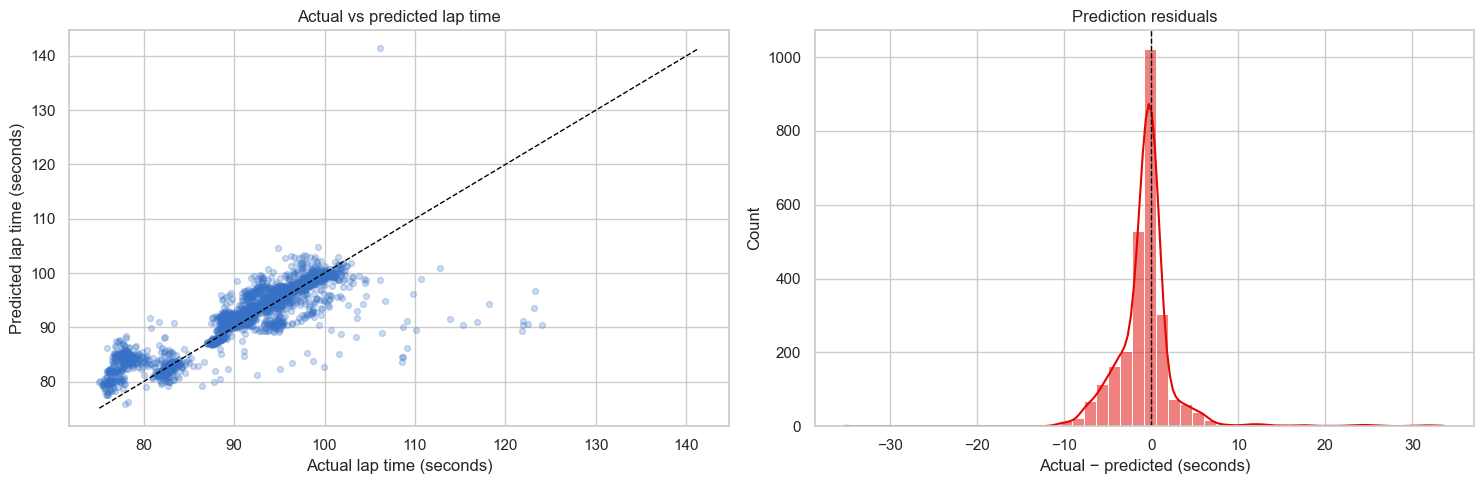

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(
    evaluation[TARGET],
    evaluation["predicted_lap_time_seconds"],
    alpha=0.25,
    s=18,
    color="#3671c6",
)
minimum = min(
    evaluation[TARGET].min(),
    evaluation["predicted_lap_time_seconds"].min(),
)
maximum = max(
    evaluation[TARGET].max(),
    evaluation["predicted_lap_time_seconds"].max(),
)
axes[0].plot(
    [minimum, maximum],
    [minimum, maximum],
    "--",
    color="black",
    linewidth=1,
)
axes[0].set_title("Actual vs predicted lap time")
axes[0].set_xlabel("Actual lap time (seconds)")
axes[0].set_ylabel("Predicted lap time (seconds)")

sns.histplot(
    evaluation["residual_seconds"],
    bins=50,
    kde=True,
    color="#e10600",
    ax=axes[1],
)
axes[1].axvline(
    0,
    linestyle="--",
    color="black",
    linewidth=1,
)
axes[1].set_title("Prediction residuals")
axes[1].set_xlabel("Actual − predicted (seconds)")

plt.tight_layout()
plt.show()


In [77]:
event_performance = (
    evaluation.groupby("event_name")
    .agg(
        laps=("absolute_error_seconds", "size"),
        mae_seconds=("absolute_error_seconds", "mean"),
        median_absolute_error=(
            "absolute_error_seconds",
            "median",
        ),
        maximum_error=("absolute_error_seconds", "max"),
    )
    .sort_values("mae_seconds")
)
event_performance


,laps,mae_seconds,median_absolute_error,maximum_error
event_name,,,,
Chinese Grand Prix,649,1.361662,0.782108,13.641527
Japanese Grand Prix,457,1.394366,0.834624,15.185829
Bahrain Grand Prix,536,1.621405,0.791025,35.230531
Saudi Arabian Grand Prix,448,2.343337,1.080299,33.623523
Australian Grand Prix,583,3.700340,3.221395,25.010965


In [78]:
print("Ten largest prediction errors:")
evaluation.nlargest(
    10,
    "absolute_error_seconds",
)[
    [
        "event_name",
        "session_name",
        "driver",
        "lap_number",
        "lap_time_seconds",
        "predicted_lap_time_seconds",
        "absolute_error_seconds",
    ]
]

Ten largest prediction errors:


,event_name,session_name,driver,lap_number,lap_time_seconds,predicted_lap_time_seconds,absolute_error_seconds
11444,Bahrain Grand Prix,Practice 3,ALO,6,106.158,141.388531,35.230531
12876,Saudi Arabian Grand Prix,Practice 2,GAS,4,124.056,90.432477,33.623523
12914,Saudi Arabian Grand Prix,Practice 2,NOR,4,121.854,89.390834,32.463166
12889,Saudi Arabian Grand Prix,Practice 2,HAM,7,122.480,90.540414,31.939586
12928,Saudi Arabian Grand Prix,Practice 2,PIA,4,121.895,90.404834,31.490166
12858,Saudi Arabian Grand Prix,Practice 2,ALO,4,121.950,91.142834,30.807166
12936,Saudi Arabian Grand Prix,Practice 2,RUS,4,123.135,93.465922,29.669078
12908,Saudi Arabian Grand Prix,Practice 2,LAW,21,123.323,96.635501,26.687499
12896,Saudi Arabian Grand Prix,Practice 2,HUL,6,116.849,90.959494,25.889506
10570,Australian Grand Prix,Practice 1,SAI,8,108.579,83.568035,25.010965


In [ ]:
if isinstance(best_model, PreviousLapDeltaRegressor):
    model_bundle = {
        "prediction_mode": "previous_lap_delta",
        "baseline_column": best_model.baseline_column,
        "estimator": best_model.estimator_,
        "features": FEATURES,
        "model_name": BEST_MODEL_NAME,
    }
else:
    model_bundle = {
        "prediction_mode": "direct",
        "estimator": best_model,
        "features": FEATURES,
        "model_name": BEST_MODEL_NAME,
    }

joblib.dump(model_bundle, MODEL_PATH)


['/Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/module_2_lap_time_prediction_v2/artifacts/lap_time_model_v2.joblib']

In [81]:
evaluation.to_csv(PREDICTIONS_PATH, index=False)

metadata = {
    "version": "standalone_v2",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "best_model": BEST_MODEL_NAME,
    "selection_metric": "rmse_seconds",
    "test_season": TEST_SEASON,
    "train_rows": int(len(train_data)),
    "test_rows": int(len(test_data)),
    "features": FEATURES,
    "target": TARGET,
    "results": model_metrics,
}
METRICS_PATH.write_text(json.dumps(metadata, indent=2))


1365

In [82]:
print("Saved dataset:", DATA_PATH)
print("Saved model:", MODEL_PATH)
print("Saved metrics:", METRICS_PATH)
print("Saved test predictions:", PREDICTIONS_PATH)

Saved dataset: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/module_2_lap_time_prediction_v2/data/lap_time_features_v2.csv
Saved model: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/module_2_lap_time_prediction_v2/artifacts/lap_time_model_v2.joblib
Saved metrics: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/module_2_lap_time_prediction_v2/artifacts/metrics_v2.json
Saved test predictions: /Users/santhoshkumarv/vs_code_projects/internship-harshith/projects/capstone_project/module_2_lap_time_prediction_v2/artifacts/test_predictions_v2.csv


In [83]:
def format_lap_time(total_seconds):
    minutes = int(total_seconds // 60)
    seconds = total_seconds - minutes * 60
    return f"{minutes}:{seconds:06.3f}"


new_lap_request = {
    "event_name": "Bahrain Grand Prix",
    "circuit": "Sakhir",
    "country": "Bahrain",
    "session_name": "Practice 2",
    "session_type": "Practice",
    "driver": "VER",
    "team": "Red Bull Racing",
    "track_status": "1",
    "season": 2025,
    "lap_number": 10,
    "session_elapsed_seconds": 2100,
    "driver_session_lap_index": 7,
    "previous_lap_seconds": 92.45,
    "rolling_3_lap_median": 92.71,
    "previous_speed_i1": 241,
    "previous_speed_i2": 268,
    "previous_speed_finish_line": 286,
    "previous_speed_trap": 315,
}

loaded_bundle = joblib.load(MODEL_PATH)
request_frame = pd.DataFrame([new_lap_request])

if loaded_bundle["prediction_mode"] == "previous_lap_delta":
    baseline_column = loaded_bundle["baseline_column"]
    predicted_delta = loaded_bundle["estimator"].predict(
        request_frame
    )
    prediction_values = (
        request_frame[baseline_column].to_numpy()
        + predicted_delta
    )
else:
    prediction_values = loaded_bundle["estimator"].predict(
        request_frame
    )

prediction_seconds = float(prediction_values[0])

prediction_response = {
    "model": BEST_MODEL_NAME,
    "predicted_lap_time_seconds": round(
        prediction_seconds,
        3,
    ),
    "predicted_lap_time": format_lap_time(
        prediction_seconds
    ),
}

prediction_response


{'model': 'gradient_boosting_delta',
 'predicted_lap_time_seconds': 93.078,
 'predicted_lap_time': '1:33.078'}